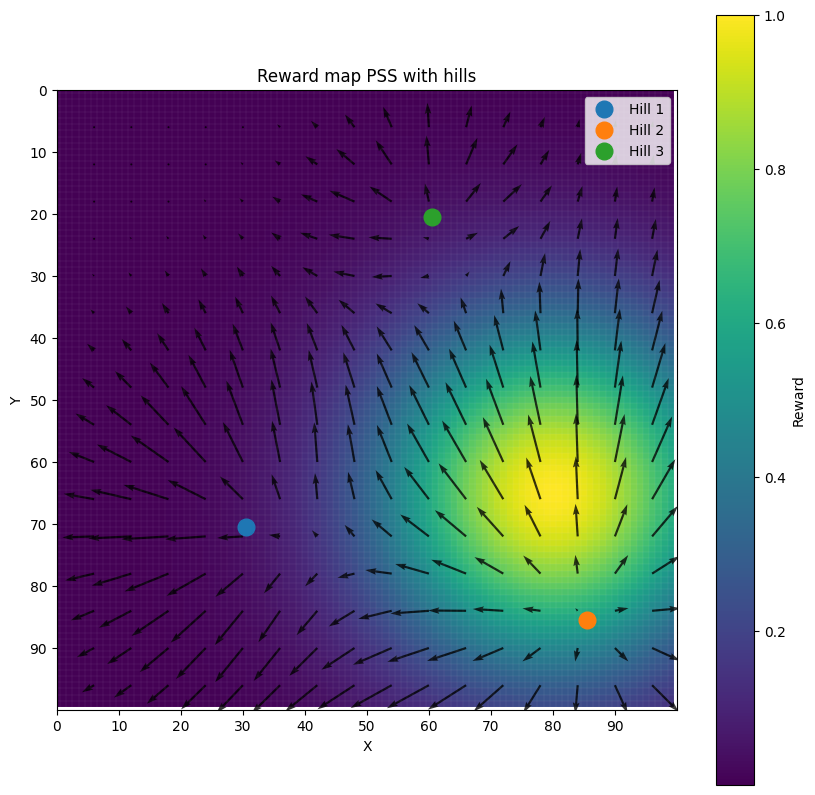

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import numpy as np


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_reward_map(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plt.show()

Desired situation 
$$( input = [s_{x}, s_{y}, a_{dx}, a_{dy}] \rightarrow_{GP} P(s'_{x}, s'_{y} | input) )\forall_{s,s' \in S, a \in A}  $$

For this I will use the Multitask GP Regression from GPyTorch based on [this paper](https://proceedings.neurips.cc/paper_files/paper/2007/file/66368270ffd51418ec58bd793f2d9b1b-Paper.pdf).

I also used [this lecture on ICM and Multitask GP](https://www.youtube.com/watch?v=ttgUJtVJthA).

In [2]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import random

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

start_state = (50, 50)

/Users/thijsvanschaik/Desktop/school/Uni/year4_last_hopefully/thesis_yehes/starting_fr_fr/BayesianRLunderUncertainty/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We call each output parameter a task, and assume these asks are not independend but in some way correlated to each other.
To model the inter-task covariance, we add an extra parameter to our cavariance calculations:

$$ cov [\mathbf{f}(\mathbf{x}), \mathbf{f}(\mathbf{x'})] = \mathbf{B} k(\mathbf{x}, \mathbf{x'}) $$

Where $k$ is the normal kernal function and $\mathbf{B}$ is a lookup table for inter-task covariance.


In [14]:
# Generate training data
walk_length = 500
actions_taken = [random.choice(list(actions.values())) for _ in range(walk_length)]
state = start_state
start_positions = [(50, 50), (20, 20), (80, 80), (20, 80), (80, 20)]

# N samples x M tasks, (0,4) as we have not sampled yet
train_x = torch.empty((0, 4), dtype=torch.float64)
train_y = torch.empty((0, 2), dtype=torch.float64)

states_visited = []

for start_pos in start_positions:
    state = start_pos
    for i in range(walk_length):
        x, y = state
        states_visited.append(state)
        state = env.transition(state=state, action=actions_taken[i])
        train_x = torch.cat((train_x, torch.tensor([[x, y, actions_taken[i][0], actions_taken[i][1]]], dtype=torch.float64)), dim=0)
        train_y = torch.cat((train_y, torch.tensor([[state[0], state[1]]], dtype=torch.float64)), dim=0)

# for i in range(walk_length):
#     x, y = state
#     state = env.transition(state=start_state, action=actions_taken[i])
#     train_x = torch.cat((train_x, torch.tensor([[start_state[0], start_state[1], actions_taken[i][0], actions_taken[i][1]]])), dim=0)
#     train_y = torch.cat((train_y, torch.tensor([[state[0], state[1]]])), dim=0)

print(train_x.shape)
print(train_y.shape)

states_visited = {x: states_visited.count(x) for x in states_visited}

torch.Size([2500, 4])
torch.Size([2500, 2])


In [ ]:
# from https://docs.gpytorch.ai/en/stable/examples/03_Multitask_Exact_GPs/Multitask_GP_Regression.html
from botorch.models.transforms.input import Normalize

# class MultitaskGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood, input_transforms=Normalize(d=4, bounds=torch.tensor([[0., 0., -1., -1.], [100., 100., 1., 1.]])))

#         self.mean_module = gpytorch.means.MultitaskMean(
#             gpytorch.means.ConstantMean(), num_tasks=2
#         )

#         # k(x,x') adjust for exprimentation
#         base_kernel = gpytorch.kernels.ScaleKernel(
#             gpytorch.kernels.RBFKernel()  # ARD learns separate lengthscale per input
#         )
#         # models inter-task covariance
#         self.covar_module = gpytorch.kernels.MultitaskKernel(
#             base_kernel, num_tasks=2, rank=1
#         )

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)
    
class BatchIndependentMultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)

        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([2]))
        
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=4, batch_shape=torch.Size([2])),
            batch_shape=torch.Size([2])
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal.from_batch_mvn(
            gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
        )


likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
model = BatchIndependentMultitaskGPModel(train_x, train_y, likelihood)

In [21]:
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls import SumMarginalLogLikelihood

class BoTorchDualSingleTaskGP(gpytorch.models.GP):
    """
    Wrapper around two BoTorch SingleTaskGP models (one per output dimension)
    with built-in normalization. Compatible with existing training/prediction code.
    """
    def __init__(self, train_x, train_y, likelihood=None):
        super().__init__()
        
        # Fix 3: Ensure float64 for numerical stability
        train_x = train_x.to(torch.float64)
        train_y = train_y.to(torch.float64)
        
        self.num_tasks = 2
        n_inputs = train_x.shape[-1]
        
        # Define input bounds for normalization
        # Format: [min_vals, max_vals] for each input dimension
        # Inputs are: x_pos (0-100), y_pos (0-100), action_x (-1 to 1), action_y (-1 to 1)
        bounds = torch.tensor([
            [0., 0., -1., -1.],  # min bounds
            [100., 100., 1., 1.]  # max bounds
        ], dtype=torch.float64)
        
        # Create two independent SingleTaskGPs with built-in normalization
        # Each predicts one output dimension
        self.gp_x = SingleTaskGP(
            train_X=train_x,
            train_Y=train_y[:, 0:1],  # First output (x coordinate)
            input_transform=Normalize(d=n_inputs, bounds=bounds),
            outcome_transform=Standardize(m=1)
        )
        
        self.gp_y = SingleTaskGP(
            train_X=train_x,
            train_Y=train_y[:, 1:2],  # Second output (y coordinate)
            input_transform=Normalize(d=n_inputs, bounds=bounds),
            outcome_transform=Standardize(m=1)
        )
        
        # Fix 4: Set minimum noise constraint to prevent numerical issues
        min_noise = 1e-4
        self.gp_x.likelihood.noise_covar.register_constraint(
            "raw_noise", gpytorch.constraints.GreaterThan(min_noise)
        )
        self.gp_y.likelihood.noise_covar.register_constraint(
            "raw_noise", gpytorch.constraints.GreaterThan(min_noise)
        )
        
        # Store training data for compatibility
        self.train_inputs = (train_x,)
        self.train_targets = train_y
        
    def forward(self, x):
        """Returns MultitaskMultivariateNormal compatible with existing code."""
        # Ensure input is float64
        x = x.to(torch.float64)
        
        # Get predictions from both GPs
        dist_x = self.gp_x(x)
        dist_y = self.gp_y(x)
        
        # Stack means: shape (n, 2)
        mean = torch.stack([dist_x.mean, dist_y.mean], dim=-1)
        
        # Build block diagonal covariance 
        # For independent outputs, covariance is block diagonal
        cov_x = dist_x.covariance_matrix  # (n, n)
        cov_y = dist_y.covariance_matrix  # (n, n)
        
        # Create MultitaskMultivariateNormal from the two independent MVNs
        # Stack the two MVNs into a batch MVN and convert
        batch_mvn = gpytorch.distributions.MultivariateNormal(
            mean=torch.stack([dist_x.mean, dist_y.mean], dim=0),  # (2, n)
            covariance_matrix=torch.stack([cov_x, cov_y], dim=0)  # (2, n, n)
        )
        
        return gpytorch.distributions.MultitaskMultivariateNormal.from_batch_mvn(batch_mvn)
    
    def train(self, mode=True):
        """Set training mode for both GPs."""
        super().train(mode)
        self.gp_x.train(mode)
        self.gp_y.train(mode)
        return self
    
    def eval(self):
        """Set evaluation mode for both GPs."""
        super().eval()
        self.gp_x.eval()
        self.gp_y.eval()
        return self
    
    def parameters(self):
        """Return all parameters from both GPs."""
        return list(self.gp_x.parameters()) + list(self.gp_y.parameters())


class DualGPMarginalLogLikelihood(gpytorch.Module):
    """
    MLL wrapper for BoTorchDualSingleTaskGP that sums the MLLs of both GPs.
    Compatible with standard training loops.
    """
    def __init__(self, likelihood, model):
        super().__init__()
        self.model = model
        self.likelihood = likelihood
        
        # Create individual MLLs for each GP
        self.mll_x = gpytorch.mlls.ExactMarginalLogLikelihood(
            model.gp_x.likelihood, model.gp_x
        )
        self.mll_y = gpytorch.mlls.ExactMarginalLogLikelihood(
            model.gp_y.likelihood, model.gp_y
        )
    
    def forward(self, output, target):
        """
        Compute sum of MLLs for both GPs.
        output: MultitaskMultivariateNormal (ignored, we recompute from individual GPs)
        target: (n, 2) tensor of targets
        """
        train_x = self.model.train_inputs[0]
        
        # Get individual GP outputs
        output_x = self.model.gp_x(train_x)
        output_y = self.model.gp_y(train_x)
        
        # Compute MLL for each
        mll_x = self.mll_x(output_x, target[:, 0])
        mll_y = self.mll_y(output_y, target[:, 1])
        
        return mll_x + mll_y


# Usage example - drop-in replacement for existing code:
# model = BoTorchDualSingleTaskGP(train_x, train_y, likelihood=None)
# likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)  # For prediction wrapping only
# mll = DualGPMarginalLogLikelihood(likelihood, model)

In [ ]:
# Instantiate the BoTorch dual GP model (drop-in replacement)
# Uncomment to use instead of BatchIndependentMultitaskGPModel

# model = BoTorchDualSingleTaskGP(train_x, train_y)
# likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
# mll = DualGPMarginalLogLikelihood(likelihood, model)

# Training loop stays the same:
# model.train()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
# for i in range(training_iterations):
#     optimizer.zero_grad()
#     output = model(train_x)
#     loss = -mll(output, train_y)
#     loss.backward()
#     optimizer.step()

# Prediction also stays the same:
# model.eval()
# with torch.no_grad():
#     predictions = likelihood(model(x_test))
#     mean = predictions.mean
#     cov = predictions.covariance_matrix

In [ ]:
def train_model_and_plot(model, likelihood, train_x, train_y, env, start_positions, training_iterations=100):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    for i in range(training_iterations):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        losses.append(loss.item())
        optimizer.step()

    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].plot(range(1, training_iterations + 1), losses)
    axs[0].set_xlabel('Iteration')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training Loss over Iterations')
    axs[0].grid(True)

    
    plt.show()

Iter 1/150 - Loss: 414.113
Iter 2/150 - Loss: 360.437
Iter 3/150 - Loss: 313.207
Iter 4/150 - Loss: 272.177
Iter 5/150 - Loss: 236.919
Iter 6/150 - Loss: 206.877
Iter 7/150 - Loss: 181.427
Iter 8/150 - Loss: 159.932
Iter 9/150 - Loss: 141.793
Iter 10/150 - Loss: 126.470
Iter 11/150 - Loss: 113.492
Iter 12/150 - Loss: 102.465
Iter 13/150 - Loss: 93.057
Iter 14/150 - Loss: 84.995
Iter 15/150 - Loss: 78.054
Iter 16/150 - Loss: 72.051
Iter 17/150 - Loss: 66.835
Iter 18/150 - Loss: 62.281
Iter 19/150 - Loss: 58.287
Iter 20/150 - Loss: 54.769
Iter 21/150 - Loss: 51.657
Iter 22/150 - Loss: 48.893
Iter 23/150 - Loss: 46.428
Iter 24/150 - Loss: 44.220
Iter 25/150 - Loss: 42.237
Iter 26/150 - Loss: 40.449
Iter 27/150 - Loss: 38.831
Iter 28/150 - Loss: 37.362
Iter 29/150 - Loss: 36.025
Iter 30/150 - Loss: 34.803
Iter 31/150 - Loss: 33.684
Iter 32/150 - Loss: 32.656
Iter 33/150 - Loss: 31.709
Iter 34/150 - Loss: 30.834
Iter 35/150 - Loss: 30.024
Iter 36/150 - Loss: 29.273
Iter 37/150 - Loss: 28.57

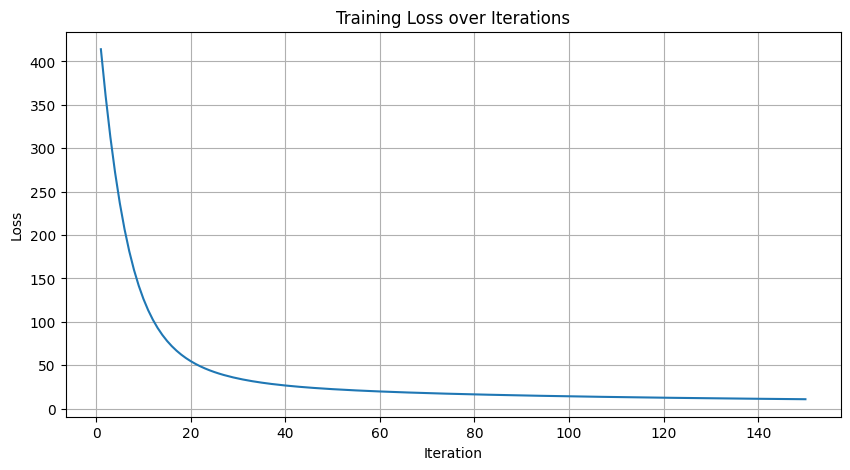

In [5]:
# from https://docs.gpytorch.ai/en/stable/examples/03_Multitask_Exact_GPs/Multitask_GP_Regression.html
training_iterations = 150

# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# Track losses for plotting
losses = []

for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    losses.append(loss.item())
    print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iterations, loss.item()))
    optimizer.step()

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, training_iterations + 1), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()

In [6]:
x_test = torch.tensor([[50, 50, 1, 0]])
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(x_test))
    mean = predictions.mean
    cov = predictions.covariance_matrix.squeeze(0)
    lower, upper = predictions.confidence_region()

print("Predicted mean:", mean)
print("Predicted covariance matrix:\n", cov)
print("95% confidence region lower bound:", lower)
print("95% confidence region upper bound:", upper)


Predicted mean: tensor([[24.0787, 24.0847]], dtype=torch.float64)
Predicted covariance matrix:
 tensor([[7.7956, 0.0000],
        [0.0000, 7.7519]], dtype=torch.float64)
95% confidence region lower bound: tensor([[18.4946, 18.5162]], dtype=torch.float64)
95% confidence region upper bound: tensor([[29.6628, 29.6531]], dtype=torch.float64)


In [7]:
# Diagnostics: check training data coverage and learned hyperparameters
test_state = (50, 50)
radius = 5

# Count samples near the test state
distances = torch.sqrt((train_x[:, 0] - test_state[0])**2 + (train_x[:, 1] - test_state[1])**2)
nearby_samples = (distances < radius).sum().item()
print(f"Training samples within {radius} units of {test_state}: {nearby_samples} / {len(train_x)}")

# Print learned hyperparameters
print("\nLearned hyperparameters:")
print(f"  Likelihood noise: {likelihood.noise.item():.4f}")
# print(f"  Task covariance matrix:\n{model.covar_module.task_covar_module.covar_matrix.evaluate()}")

# Check variance of train_y
print(f"\nTraining data statistics:")
print(f"  train_y mean: {train_y.mean(dim=0)}")
print(f"  train_y std: {train_y.std(dim=0)}")

Training samples within 5 units of (50, 50): 1 / 2500

Learned hyperparameters:
  Likelihood noise: 2.5679

Training data statistics:
  train_y mean: tensor([21.3952, 67.3676], dtype=torch.float64)
  train_y std: tensor([35.1220, 19.0130], dtype=torch.float64)


Original covariance matrix:
 [[6.25153327 0.        ]
 [0.         6.44899625]] 
 new covariance matrix:
 [[6.25153427 0.        ]
 [0.         6.44899725]]
Learned noise per task: tensor([2.5693, 2.5658], grad_fn=<AddBackward0>)
Original covariance matrix:
 [[6.25480435 0.        ]
 [0.         6.47712991]] 
 new covariance matrix:
 [[6.25480535 0.        ]
 [0.         6.47713091]]
Learned noise per task: tensor([2.5693, 2.5658], grad_fn=<AddBackward0>)
Original covariance matrix:
 [[6.0301914  0.        ]
 [0.         6.20034701]] 
 new covariance matrix:
 [[6.0301924  0.        ]
 [0.         6.20034801]]
Learned noise per task: tensor([2.5693, 2.5658], grad_fn=<AddBackward0>)
Original covariance matrix:
 [[5.96523477 0.        ]
 [0.         6.07646128]] 
 new covariance matrix:
 [[5.96523577 0.        ]
 [0.         6.07646228]]
Learned noise per task: tensor([2.5693, 2.5658], grad_fn=<AddBackward0>)


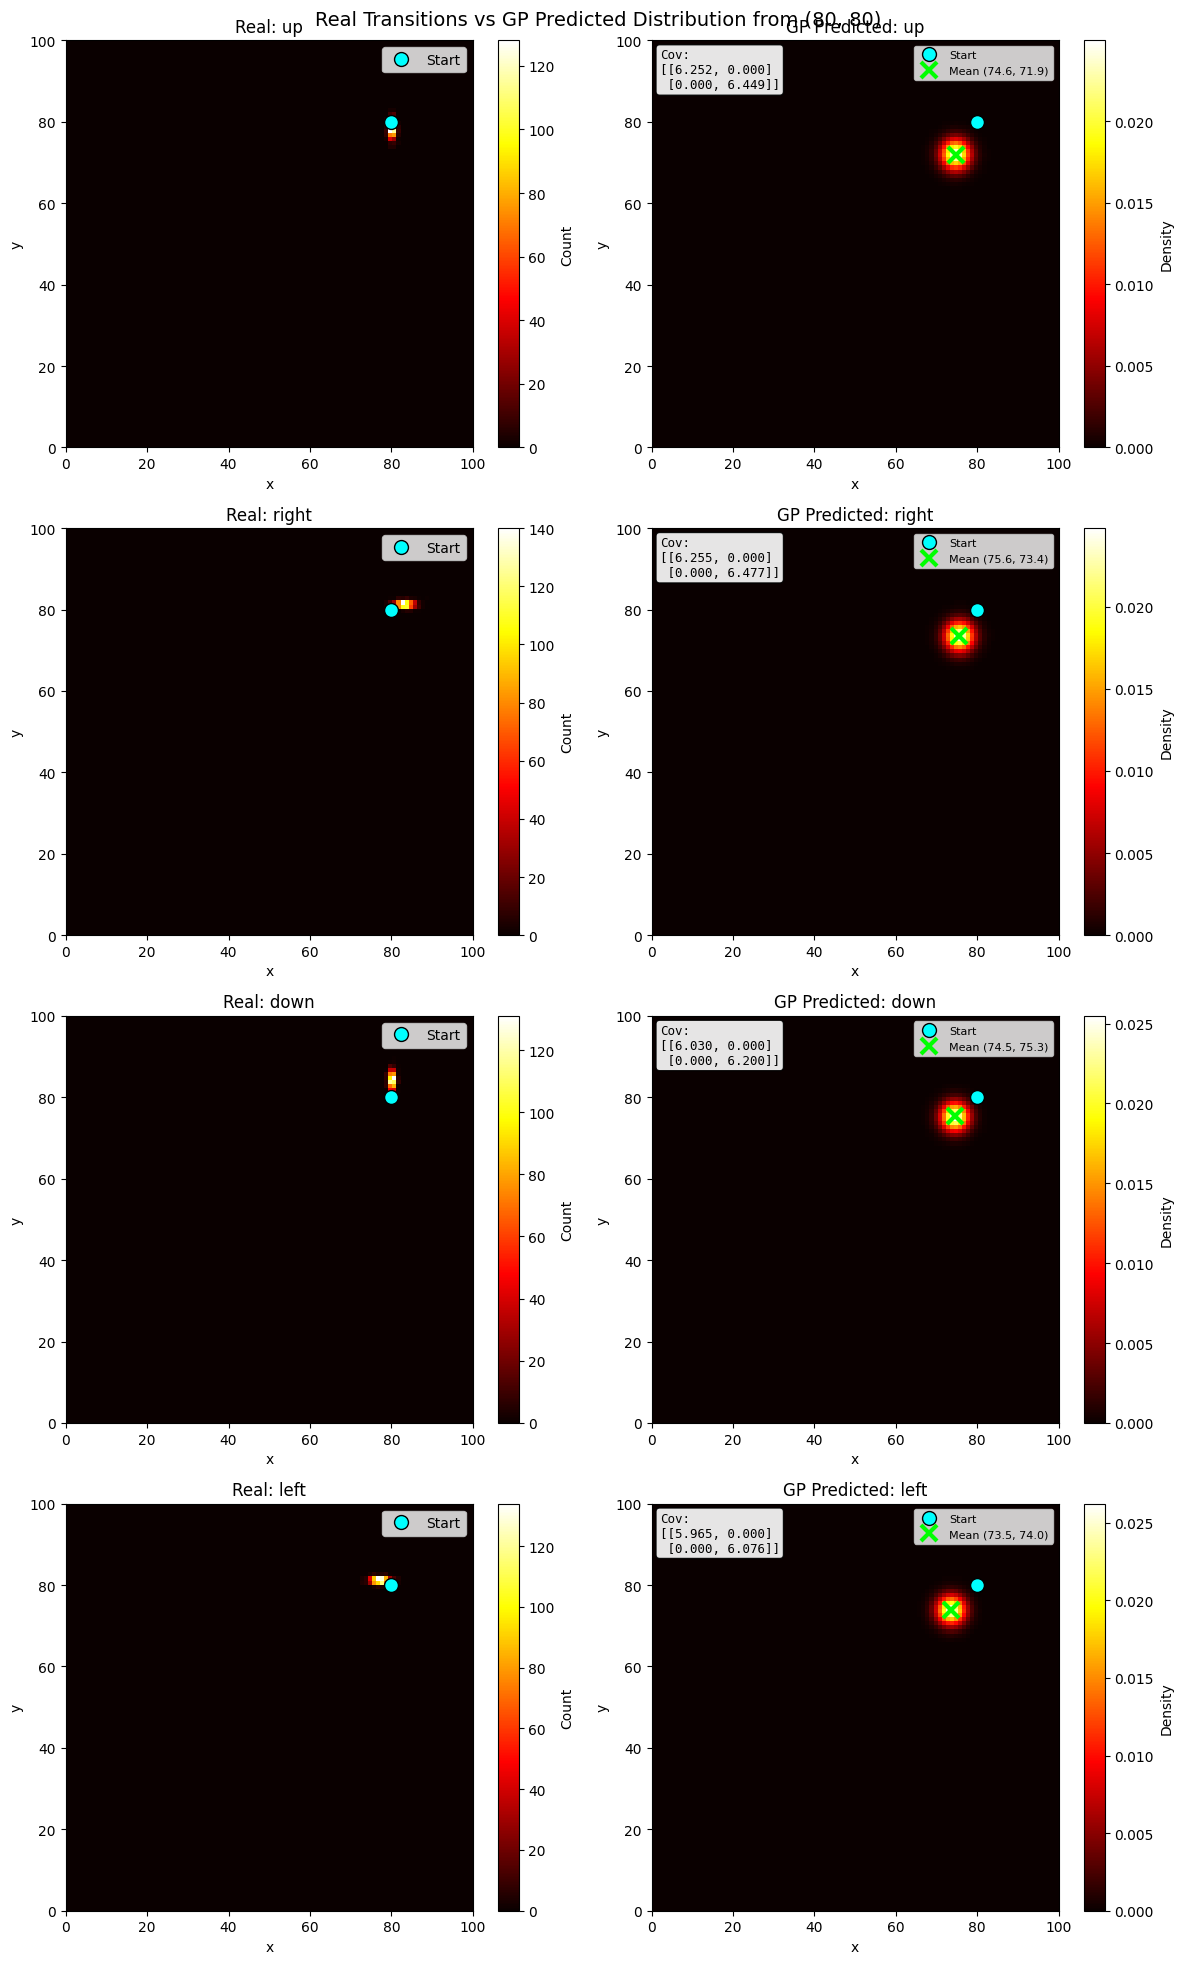

In [8]:
# Compare GP predicted distribution vs real transition distribution
# Real: heatmap of samples. GP: 2D Gaussian density from covariance matrix
from scipy.stats import multivariate_normal

start_state = (80, 80)
n_samples = 1000

fig, axs = plt.subplots(4, 2, figsize=(12, 20))

for row, (action_name, action) in enumerate(actions.items()):
    ax_real = axs[row, 0]
    ax_gp = axs[row, 1]
    
    # Build input for GP
    x_input = torch.tensor([[start_state[0], start_state[1], action[0], action[1]]], dtype=torch.float32)
    
    # Get GP prediction distribution
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(x_input))
        pred_mean = pred.mean.squeeze().numpy()
        # Get the full covariance and extract 2x2 for our single point
        full_cov = pred.covariance_matrix
        if full_cov.dim() == 3:
            pred_cov = full_cov[0].numpy()
        else:
            pred_cov = full_cov.numpy()
        lower, upper = pred.confidence_region()
        lower = lower.squeeze().numpy()
        upper = upper.squeeze().numpy()
    
    # Sample from real environment
    counts_real = np.zeros((100, 100))
    for _ in range(n_samples):
        x, y = env.transition(start_state, action)
        counts_real[y, x] += 1
    
    x0, y0 = start_state
    
    # Plot real heatmap
    im_real = ax_real.imshow(counts_real, cmap='hot', origin='lower',
                              extent=[0, 100, 0, 100])
    ax_real.plot(x0, y0, 'o', markersize=10, label='Start', color='cyan', markeredgecolor='black')
    ax_real.set_title(f"Real: {action_name}")
    ax_real.set_xlabel('x')
    ax_real.set_ylabel('y')
    ax_real.legend()
    plt.colorbar(im_real, ax=ax_real, label='Count')
    
    # Create 2D Gaussian density from GP prediction
    # Make covariance positive definite by using absolute eigenvalues
    eigenvalues, eigenvectors = np.linalg.eigh(pred_cov)
    eigenvalues = np.abs(eigenvalues) + 1e-6  # Ensure positive
    pred_cov_fixed = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    print("Original covariance matrix:\n", pred_cov, "\n new covariance matrix:\n", pred_cov_fixed)
    
    # Create grid for density evaluation
    x_grid = np.linspace(0, 100, 100)
    y_grid = np.linspace(0, 100, 100)    
    print(f"Learned noise per task: {likelihood.task_noises}")
    X, Y = np.meshgrid(x_grid, y_grid)
    pos = np.dstack((X, Y))
    
    # Evaluate 2D Gaussian PDF
    rv = multivariate_normal(pred_mean, pred_cov_fixed)
    Z = rv.pdf(pos)
    
    # Plot GP density as heatmap
    im_gp = ax_gp.imshow(Z, cmap='hot', origin='lower', extent=[0, 100, 0, 100])
    ax_gp.plot(x0, y0, 'o', markersize=10, label='Start', color='cyan', markeredgecolor='black')
    ax_gp.plot(pred_mean[0], pred_mean[1], 'x', markersize=12, color='lime', 
               markeredgewidth=3, label=f'Mean ({pred_mean[0]:.1f}, {pred_mean[1]:.1f})')
    
    ax_gp.set_title(f"GP Predicted: {action_name}")
    ax_gp.set_xlabel('x')
    ax_gp.set_ylabel('y')
    ax_gp.legend(loc='upper right', fontsize=8)
    plt.colorbar(im_gp, ax=ax_gp, label='Density')
    
    # Add covariance matrix text in corner
    cov_text = f"Cov:\n[[{pred_cov[0,0]:.3f}, {pred_cov[0,1]:.3f}]\n [{pred_cov[1,0]:.3f}, {pred_cov[1,1]:.3f}]]"
    ax_gp.text(0.02, 0.98, cov_text,
               transform=ax_gp.transAxes, fontsize=9, verticalalignment='top',
               horizontalalignment='left', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

plt.suptitle(f'Real Transitions vs GP Predicted Distribution from {start_state}', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Example model output and how to sample from it.
mean = torch.tensor([10.0, 5.0])

cov = torch.tensor([
    [0.4, 0.1],
    [0.1, 0.3]
])

dist = torch.distributions.MultivariateNormal(mean, cov)

samples = dist.sample((5,))
print(samples)

tensor([[10.0712,  5.1164],
        [ 9.7747,  5.5065],
        [ 9.3130,  4.4658],
        [10.4219,  4.8166],
        [ 9.6272,  5.0986]])


In [10]:
# Heatmap of model log likelihood across state space
# For each grid cell, compute average log likelihood over all actions
def plot_ll_heatmap(model, 
                    likelihood, 
                    start_positions, 
                    env, 
                    actions, 
                    grid_resolution=100, 
                    n_samples_per_cell=50, 
                    threshold=-10,
                    red_max=-2,
                    ax=None
                    ):
    
    from matplotlib.colors import LinearSegmentedColormap, ListedColormap
    import matplotlib.colors as mcolors

    grid_resolution = 100  # 100x100 grid
    x_coords = np.linspace(0, 99, grid_resolution)
    y_coords = np.linspace(0, 99, grid_resolution)

    log_likelihood_map = np.zeros((grid_resolution, grid_resolution))
    n_samples_per_cell = 50  # samples to estimate true distribution

    model.eval()
    likelihood.eval()

    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            state = (int(x), int(y))
            total_log_prob = 0
            
            for action_name, action in actions.items():
                # Get GP prediction
                x_input = torch.tensor([[state[0], state[1], action[0], action[1]]], dtype=torch.float32)
                
                with torch.no_grad(), gpytorch.settings.fast_pred_var():
                    pred = likelihood(model(x_input))
                    pred_mean = pred.mean.squeeze()
                    pred_cov = pred.covariance_matrix.squeeze(0)
                
                # Sample from real environment and compute log prob under GP
                for _ in range(n_samples_per_cell):
                    next_state = env.transition(state, action)
                    next_state_tensor = torch.tensor([next_state[0], next_state[1]], dtype=torch.float32)
                    
                    # Create distribution and compute log prob
                    try:
                        dist = torch.distributions.MultivariateNormal(pred_mean, pred_cov)
                        log_prob = dist.log_prob(next_state_tensor).item()
                    except:
                        # If covariance is not positive definite, use diagonal approximation
                        log_prob = -10  # penalty for numerical issues
                    
                    total_log_prob += log_prob
            
            # Average log likelihood for this cell
            log_likelihood_map[j, i] = total_log_prob / (len(actions) * n_samples_per_cell)
        
        if (i + 1) % 10 == 0:
            print(f"Processed row {i+1}/{grid_resolution}")

    # Create custom colormap: viridis for values <= -10, red gradient for > -10
    vmin, vmax = log_likelihood_map.min(), log_likelihood_map.max()
    threshold = -10
    red_max = -2  # dark red at this value

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Plot main heatmap with viridis for values below threshold
    plot_data_viridis = np.where(log_likelihood_map <= threshold, log_likelihood_map, np.nan)
    im = ax.imshow(plot_data_viridis, cmap='viridis', origin='lower', 
                extent=[0, 100, 0, 100], aspect='equal', vmin=vmin, vmax=threshold)

    # Create red gradient colormap (light red to dark red)
    reds_cmap = LinearSegmentedColormap.from_list('custom_reds', ['#ffcccc', '#ff0000', '#8b0000'])

    # Plot red gradient for values > -10
    plot_data_red = np.where(log_likelihood_map > threshold, log_likelihood_map, np.nan)
    im_red = ax.imshow(plot_data_red, cmap=reds_cmap, origin='lower', 
                    extent=[0, 100, 0, 100], aspect='equal', vmin=threshold, vmax=red_max)

    # Add colorbars
    cbar1 = plt.colorbar(im, ax=ax, label='Log Likelihood (poor)', location='left', pad=0.12)
    cbar2 = plt.colorbar(im_red, ax=ax, label='Log Likelihood (good)', location='right')

    # Mark training start positions
    for pos in start_positions:
        ax.plot(pos[0], pos[1], 'w*', markersize=15, markeredgecolor='black', markeredgewidth=1)

    env.plot_hills(ax=ax)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'GP Model Log Likelihood Heatmap\n(White stars = training start positions)')
    plt.tight_layout()
    plt.show()

    good_mask = log_likelihood_map > threshold
    print(f"\nLog likelihood statistics:")
    print(f"  Min: {log_likelihood_map.min():.2f}")
    print(f"  Max: {log_likelihood_map.max():.2f}")
    print(f"  Mean: {log_likelihood_map.mean():.2f}")
    print(f"  Cells with LL > {threshold}: {good_mask.sum()} / {log_likelihood_map.size}")

Processed row 10/100
Processed row 20/100
Processed row 30/100
Processed row 40/100
Processed row 50/100
Processed row 60/100
Processed row 70/100
Processed row 80/100
Processed row 90/100
Processed row 100/100


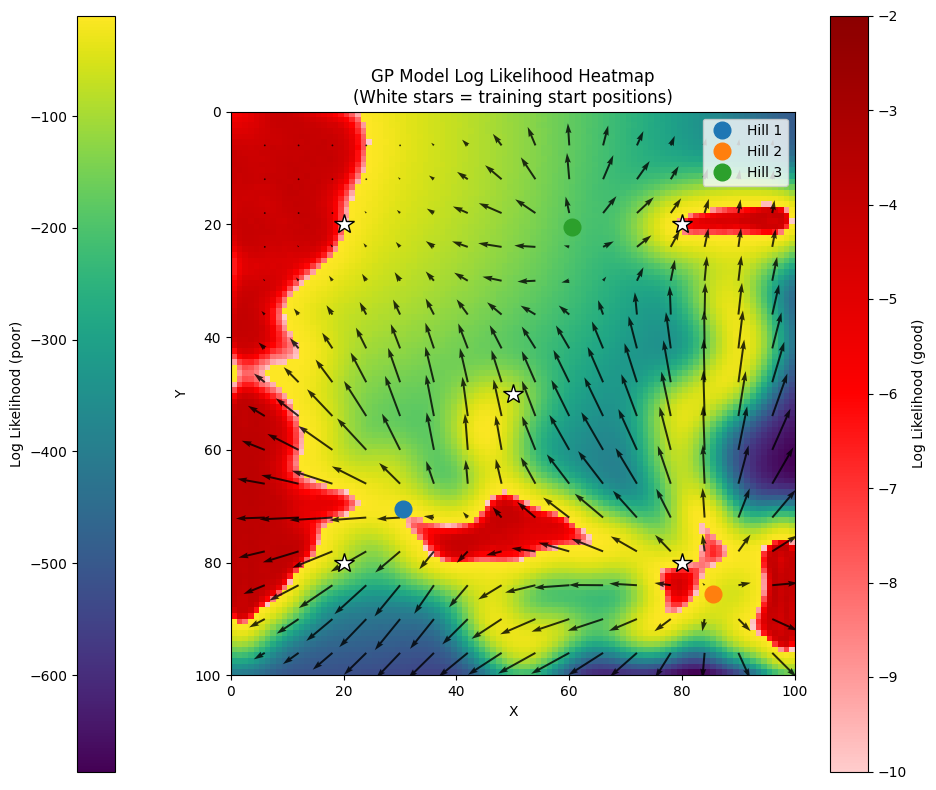


Log likelihood statistics:
  Min: -686.33
  Max: -3.67
  Mean: -139.99
  Cells with LL > -10: 1903 / 10000


In [11]:
plot_ll_heatmap(model, likelihood, start_positions, env, actions)

In [24]:
def train_model_and_plot(model, 
                        likelihood, 
                         train_x, 
                         train_y, 
                         env, 
                         start_positions, 
                         training_iterations=100, 
                         ax=None, 
                         mll_class=gpytorch.mlls.ExactMarginalLogLikelihood
                         ):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = mll_class(likelihood, model)

    losses = []
    for i in range(training_iterations):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        losses.append(loss.item())
        optimizer.step()

    if ax is None:
        fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].plot(range(1, training_iterations + 1), losses)
    axs[0].set_xlabel('Iteration')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training Loss over Iterations')
    axs[0].grid(True)

    plot_ll_heatmap(model, likelihood, start_positions, env, actions, ax=axs[1])
    
    plt.show()

def show_visited_overlay(states_visited, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
        env.plot_reward_map(ax=ax)
        env.plot_hills(ax=ax)

    grid_size = 100
    visit_counts = np.zeros((grid_size, grid_size))

    for state, count in states_visited.items():
        x, y = state
        if 0 <= x < grid_size and 0 <= y < grid_size:
            visit_counts[y, x] = count 

    # Overlay visit counts as a heatmap
    im = ax.imshow(visit_counts, cmap='Reds', alpha=0.6, origin='lower', extent=[0, 100, 0, 100])
    plt.colorbar(im, ax=ax, label='Visit Count')
    
    ax.set_title('State Visit Counts Overlay')
    plt.show()

_LinAlgError: linalg.cholesky: (Batch element 0): The factorization could not be completed because the input is not positive-definite (the leading minor of order 115 is not positive-definite).

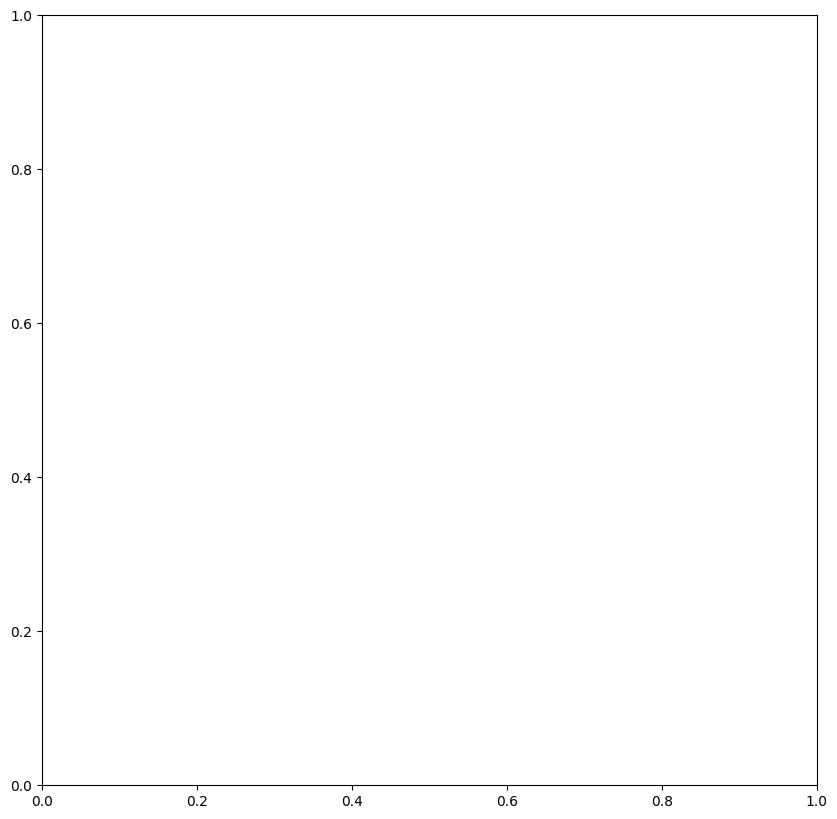

In [25]:
model_test = BoTorchDualSingleTaskGP(train_x, train_y)
likelihood_test = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)

fig, ax = plt.subplots(figsize=(10, 10))
train_model_and_plot(model_test, likelihood_test, train_x, train_y, env, start_positions, training_iterations=100, ax=ax, mll_class=DualGPMarginalLogLikelihood)
show_visited_overlay(states_visited, ax=ax)